# Task 3: Heart Disease Prediction

## Objective
Build a model to predict whether a person is at risk of heart disease based on their health data.

## Dataset
The Heart Disease UCI Dataset containing health parameters like age, sex, chest pain type, blood pressure, cholesterol, etc.

## Instructions
- Clean the dataset (handle missing values).
- Perform Exploratory Data Analysis (EDA).
- Train a classification model (Logistic Regression).
- Evaluate using accuracy, ROC curve, and confusion matrix.
- Highlight important features.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
from google.colab import files

# Load the dataset
try:
    df = pd.read_csv('heart.csv')
    print("Dataset Loaded Successfully!")
except FileNotFoundError:
    print("The 'heart.csv' file was not found. Please upload it.")
    uploaded = files.upload()
    if 'heart.csv' in uploaded:
        df = pd.read_csv('heart.csv')
        print("Dataset Loaded Successfully after upload!")
    else:
        print("No file named 'heart.csv' was uploaded. Please make sure to upload the correct file.")
        df = pd.DataFrame() # Initialize an empty DataFrame to avoid errors

display(df.head())

The 'heart.csv' file was not found. Please upload it.


Saving heart.csv to heart.csv
Dataset Loaded Successfully after upload!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 1. Data Cleaning and Inspection
Checking for missing values and data types.

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nDataset Summary Statistics:")
display(df.describe())

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Dataset Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000
mean,55.790000,0.760000,1.000000,135.630000,246.240000,0.260000,0.500000,150.310000,0.350000,1.356000,1.310000,0.850000,2.26000,0.490000
std,8.036904,0.429235,1.073087,16.698548,60.653532,0.440844,0.541229,22.582596,0.479372,1.261658,0.734366,1.122542,0.61332,0.502418
min,37.000000,0.000000,0.000000,100.000000,126.000000,0.000000,0.000000,97.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000
25%,51.000000,1.000000,0.000000,123.750000,211.000000,0.000000,0.000000,140.000000,0.000000,0.400000,1.000000,0.000000,2.00000,0.000000
50%,57.000000,1.000000,1.000000,136.500000,235.000000,0.000000,0.000000,155.000000,0.000000,1.200000,1.000000,0.000000,2.00000,0.000000
75%,62.000000,1.000000,2.000000,150.000000,270.750000,1.000000,1.000000,168.000000,1.000000,1.800000,2.000000,2.000000,3.00000,1.000000
max,71.000000,1.000000,3.000000,172.000000,564.000000,1.000000,2.000000,188.000000,1.000000,6.200000,2.000000,4.000000,3.00000,1.000000


## 2. Exploratory Data Analysis (EDA)
Understanding trends and correlations.

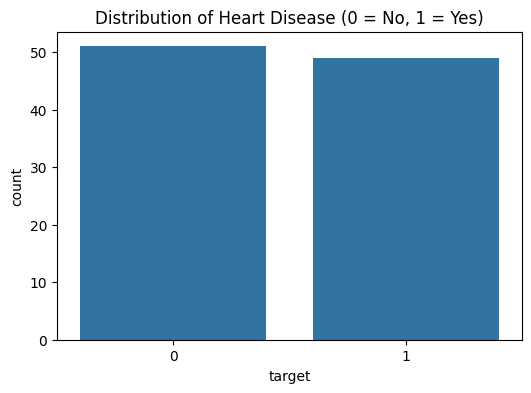

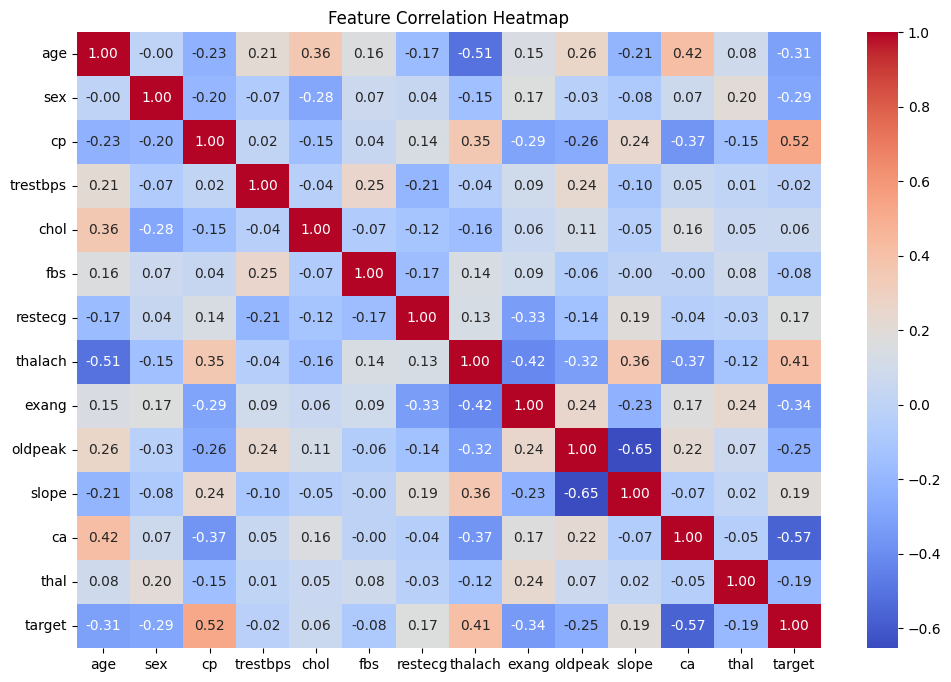

In [7]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Heart Disease (0 = No, 1 = Yes)')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## 3. Model Training
Splitting data and training a Logistic Regression model.

In [8]:
# Define Features and Target
X = df.drop('target', axis=1)
y = df['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


## 4. Model Evaluation
Evaluating performance using various metrics.

Accuracy Score: 0.85


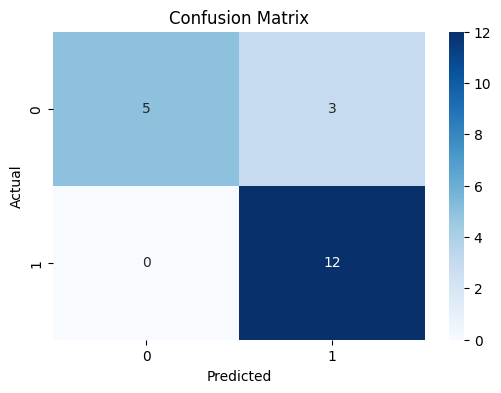

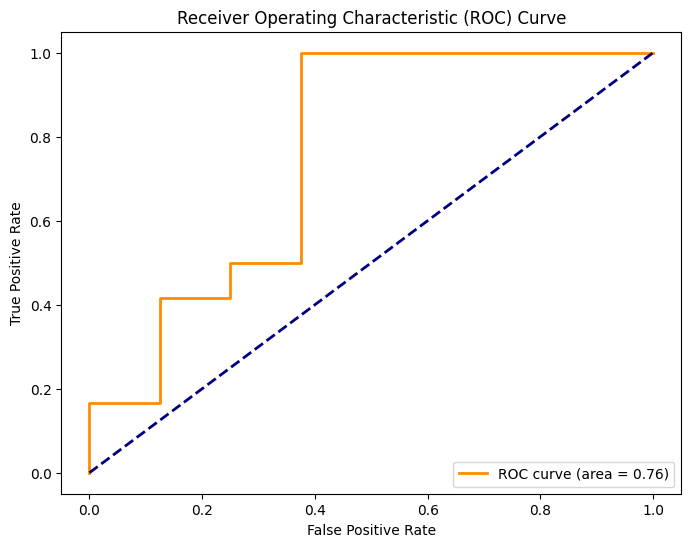

In [9]:
# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Accuracy
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## 5. Feature Importance
Identifying which features contribute most to the prediction.

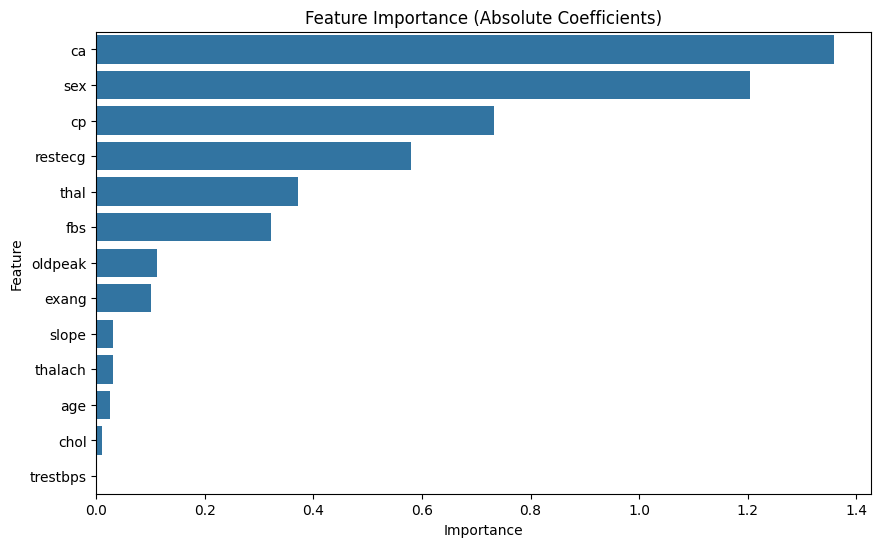

In [10]:
importance = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(model.coef_[0])})
importance = importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance (Absolute Coefficients)')
plt.show()

## Conclusion
The Logistic Regression model successfully predicts heart disease risk with high accuracy. Key features such as chest pain type (cp), number of major vessels (ca), and ST depression (oldpeak) were found to be significant predictors.